In [1]:
import pandas as pd
from fista.lr import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.6, random_state=1)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=1)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train))
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [3]:
lr = LogisticRegression(lmbd = 1, max_iter = 1000, tol = 1e-4)
lr.fit(X_train, y_train)
pred = lr.predict_proba(X_test) > 0.5
ba = balanced_accuracy_score(y_test, pred)
print(f"Balanced accuracy for test set and lambda = 1: {ba}")

Balanced accuracy for test set and lambda = 1: 0.9852941176470589


/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(


In [4]:
# sets the optimal lambda and corresponding betas 
lr.validate(X_valid, y_valid, measure="bal_acc")
pred = lr.predict_proba(X_test) > 0.5
ba = balanced_accuracy_score(y_test, pred)
print(f"Best lambda based on balanced accuracy on validation set: {lr.lmbd}")
print(f"Balanced accuracy on test set for optimized lambda: {ba}")

/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 0.001, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 0.005, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 0.01, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 0.05, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 0.1, max_iter = 1000 and tol = 0.0001 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 0.3, max_iter = 1000 and tol = 0.0001 the algorithm did not 

Best lambda based on balanced accuracy on validation set: 0.05
Balanced accuracy on test set for optimized lambda: 0.9580882352941176


In [5]:
lr.beta

0     -0.000000
1      0.404369
2     -0.007630
3     -0.000000
4      1.237740
5      3.273558
6      0.075096
7     -8.606784
8     -0.170215
9      2.861668
10   -10.306563
11    -1.262222
12    -0.079966
13    -0.036814
14     3.064960
15     3.443393
16     0.000000
17    -5.778446
18    -1.156520
19    10.028056
20    -3.484326
21    -3.767916
22    -2.266711
23    -1.303126
24    -1.997053
25    -2.463827
26    -2.499038
27     0.848495
28    -0.971026
29    -7.360655
dtype: float64

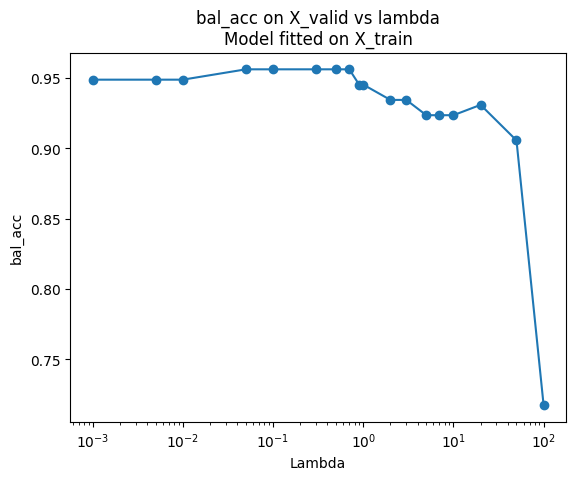

In [6]:
lr.plot("bal_acc")

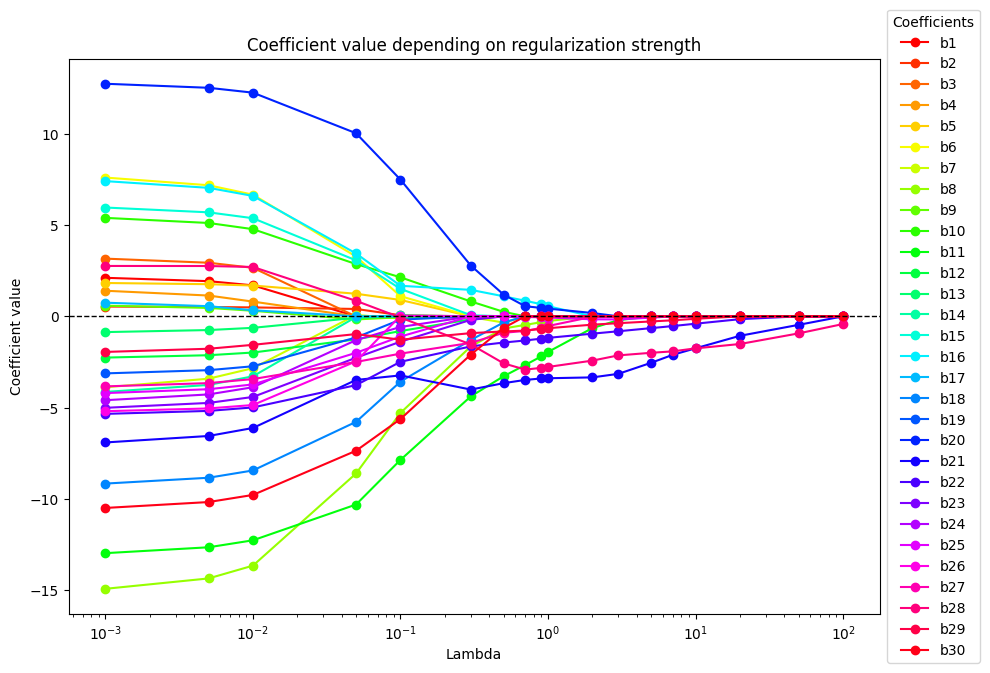

In [7]:
lr.plot_coefficients()